# Regresión lineal para predicción de progresión de diabetes
- age: Representa la edad del paciente, normalizada (no es la edad real, sino una representación estandarizada).
- sex: Sexo del paciente, representado como una variable numérica normalizada (valores entre -0.5 y 0.5).
- bmi: Índice de Masa Corporal (Body Mass Index, BMI), una medida del peso relativo al cuadrado de la altura.
- bp:
Promedio de presión arterial (Blood Pressure, BP), normalizada.
- s1: Nivel sérico de lípidos totales (colesterol total).
- s2: Nivel sérico de lipoproteínas de baja densidad (LDL, “colesterol malo”).
- s3: Nivel sérico de lipoproteínas de alta densidad (HDL, “colesterol bueno”).
- s4: Relación entre el colesterol total y HDL.
- s5: Nivel sérico de triglicéridos, representado como una medida numérica normalizada.
- s6: Nivel sérico de glucosa en ayuno, una medida clave en el monitoreo de la diabetes.

In [ ]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Cargar el conjunto de datos
diabetes_data = load_diabetes()

# Convertir el conjunto de datos a un DataFrame para facilitar su manipulación
df = pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names)
df['target'] = diabetes_data.target  # Agregar la variable objetivo al DataFrame

# Mostrar las primeras filas del DataFrame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
# Mostrar información general del dataset
print("Información general del dataset:")
print(df.info())

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None


In [3]:
# Mostrar estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17   
std    4.761905e-02  4.

In [4]:
# Verificar valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


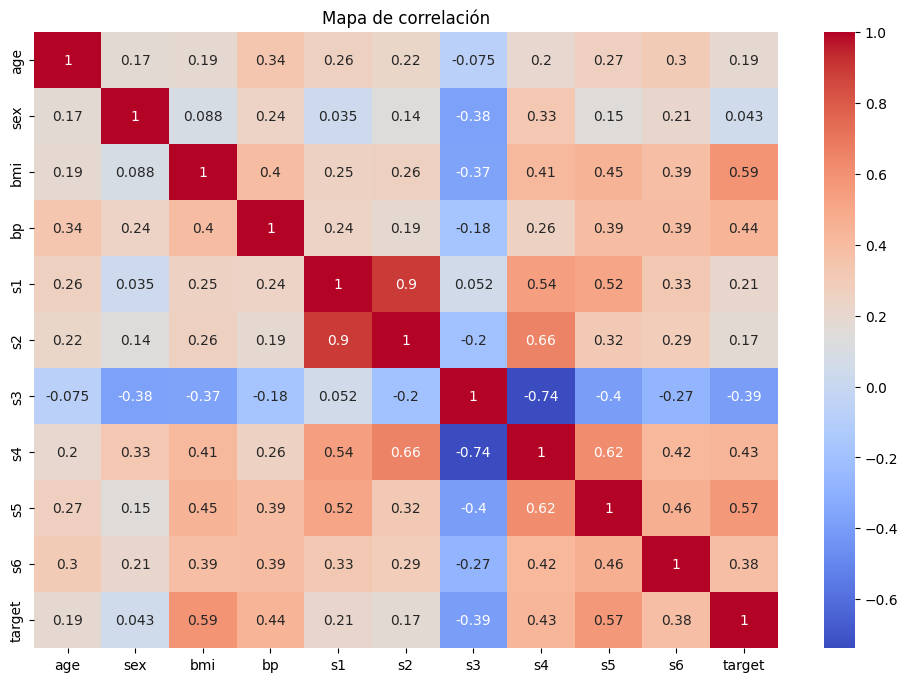

In [6]:
#Aquí buscamos que variables son las que más se relacionan con el target
# Importar seaborn
import seaborn as sns

# Crear mapa de correlación
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# Mostrar gráfica
plt.title("Mapa de correlación")
plt.show()

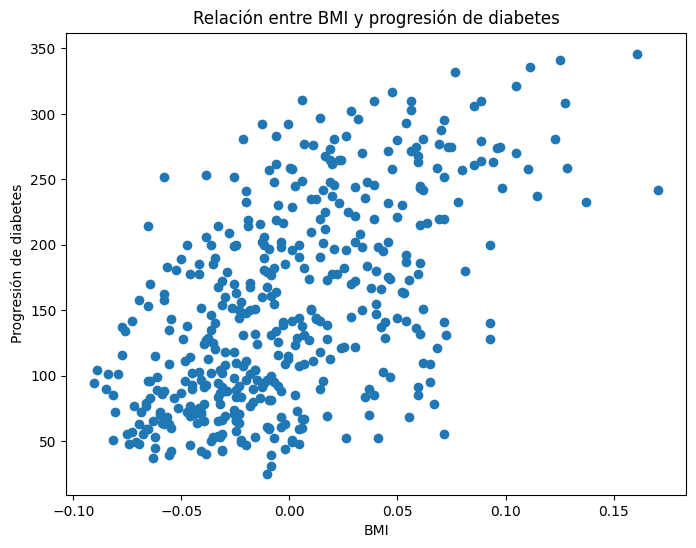

In [7]:
# Relación entre BMI y progresión de diabetes
plt.figure(figsize=(8,6))

plt.scatter(df['bmi'], df['target'])

plt.xlabel('BMI')
plt.ylabel('Progresión de diabetes')
plt.title('Relación entre BMI y progresión de diabetes')

plt.show()

In [8]:
# Separar variables independientes y variable objetivo
X = df.drop(columns=['target'])
y = df['target']

In [10]:
#Aqui buscaremos divirdir los datos del entrenamiento y la prueba
# Importar train_test_split
from sklearn.model_selection import train_test_split

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Mostrar tamaños
print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (353, 10)
Tamaño prueba: (89, 10)


In [11]:
#Ahora seguimos con le escalado de datos
# Importar StandardScaler
from sklearn.preprocessing import StandardScaler

# Crear scaler
scaler = StandardScaler()

# Ajustar y transformar entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar prueba
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Una vez escalados los datos vamos a la parte del entrenamiento del modelo, donde se encutran coheficientes y se ajusta la regresion lineal 

# Importar modelo
from sklearn.linear_model import LinearRegression

# Crear modelo
model = LinearRegression()

# Entrenar modelo
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
#Empezamos con pequeñas predicciones para probar

# Realizar predicciones
y_pred = model.predict(X_test_scaled)

# Mostrar primeras predicciones
print("Primeras predicciones:")
print(y_pred[:10])

Primeras predicciones:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


In [ ]:
#Ahora evaluamos al modelo

# Importar métricas
from sklearn.metrics import mean_squared_error, r2_score

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Mostrar resultados
print("Métricas del modelo:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Métricas del modelo:
MSE: 2900.19
RMSE: 53.85
R2 Score: 0.45


Aquí si ponemos atencion a las tericas podemos ver los datos más importantes como MSE, RMSE y R^2, ahora mismo me centrare en R^2 y RMSE
- En primer lugar podemos observar que el vaor de R^2 se encuentra entre 0 y 1, un poco más cerca de 0 pero no es un mal puntaje, pero podemos observar que nuestro modelo aun puede mejorar bastante su captura de la proporcion de variabilidad de los datos.
- En cuanto al valor de RMSE podemos observar que el valor es bajo, por lo cual vemos que se comete un error de 53.85 unidades al predecir, no es valor alarmante pero dependiendo de la cantidad de datos es un valor que debemos procurar que no suba y de ser posible que diminuya.

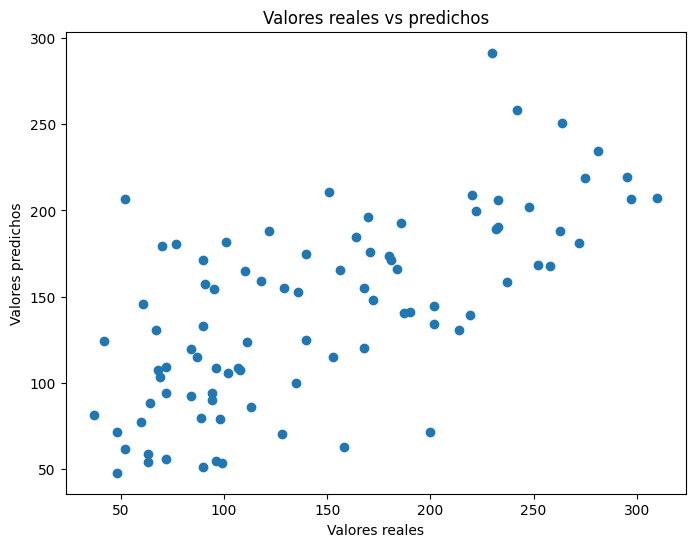

In [ ]:
#Ahora vamos a compara los valores reales con los valores predichos, con el fin de medir que tan bueno es el modelo.
#Esto lo vemos interpretando una linea diagonal imaginaria y entre más cerca este de la linea mejor es el modelo 

# Comparar valores reales vs predichos
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")

plt.show()